#### Build a basic Chat- Bot with Langgraph (GRAPH API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph , START, END
from langgraph.graph.message import add_messages
# here add_messages is reducers used to store conversion in state in form of list



In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)


In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()


True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
# method to import llm


llm= ChatGroq(model="openai/gpt-oss-20b")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000268F85C4F50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000268F8724C10>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [7]:
llm = init_chat_model("groq:openai/gpt-oss-20b")

In [8]:
### creating node def // node functionality

def chatbot(state:State):
    return{"messages":[llm.invoke(state["messages"])]}

In [9]:
graph_builder = StateGraph(State)

###Adding node
graph_builder.add_node("llmchatbot",chatbot)

## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)


## Complie the graph 
graph = graph_builder.compile()

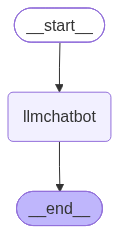

In [10]:
### visualizing the graph 

from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [11]:
graph.invoke({"message":"Hi"}) ### this not work the code below work well

BadRequestError: Error code: 400 - {'error': {'message': "'messages' : minimum number of items is 1", 'type': 'invalid_request_error'}}

In [11]:
response = graph.invoke({
    "messages": [
        {"role": "user", "content": "Hi"}
    ]
})

print(response["messages"][-1].content)

Hello! 👋 How can I help you today?


In [12]:
for event in graph.stream({"messages":"hi How are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hi! I’m doing great, thanks for asking. How about you?


ChatBot with Tool

In [13]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API',
   'score': 0.95386744,
   'raw_content': None,
   'id': '53aa5a-00'},
  {'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? | IBM'

In [14]:
### Custom function
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """Add two numbers.

    Args:
        a: First number.
        b: Second number.
    """
    return a + b

tools = [add]
llm_with_tool = llm.bind_tools(tools)

In [15]:
llm_with_tool 

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000268F8727150>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000268F8727E90>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'Add two numbers.\n\n    Args:\n        a: First number.\n        b: S

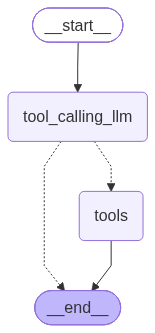

In [16]:
### State Graph 

from langgraph.graph import StateGraph , START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

### Adding Edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ## If the latest message (result) fro massistant is a tool call -> tools_condition routes to tools
    ## If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## complie the graph


graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [17]:
response = graph.invoke({"messages":"what is the recent ai news"})



In [18]:
response['messages'][-1].content

'Below is a quick‑look snapshot of the most talked‑about AI developments and headlines that have been making the news in the last few weeks (and a few that have been shaping the broader conversation as of mid‑2024).  \n\n| Date | Source / Platform | Key Take‑away | Why it matters |\n|------|-------------------|---------------|----------------|\n| **Oct\u202f2024** | **OpenAI** | *Launch of GPT‑4o‑Plus* – a new “o” (omni‑modal) variant that supports richer image‑and‑video inputs, improved context handling (up to 25\u202fk tokens), and lower‑latency inference on the new Azure‑OpenAI “Omni” tier. | Gives developers a cheaper, faster way to build multimodal apps, and pushes the envelope on what a single model can do. |\n| **Oct\u202f2024** | **Google DeepMind** | *Gemini‑4* – the next step after Gemini‑3. It includes 1.5\u202f× the parameters, a new “memory‑augmented” architecture that can keep track of longer conversations, and a “code‑generation‑plus” mode that can run Python directly in

In [19]:
## way of writing 
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news
================================== Ai Message ==================================

Below is a quick‑look snapshot of the most talked‑about AI developments and headlines that have been making the news in the last few weeks (and a few that have been shaping the broader conversation as of mid‑2024).  

| Date | Source / Platform | Key Take‑away | Why it matters |
|------|-------------------|---------------|----------------|
| **Oct 2024** | **OpenAI** | *Launch of GPT‑4o‑Plus* – a new “o” (omni‑modal) variant that supports richer image‑and‑video inputs, improved context handling (up to 25 k tokens), and lower‑latency inference on the new Azure‑OpenAI “Omni” tier. | Gives developers a cheaper, faster way to build multimodal apps, and pushes the envelope on what a single model can do. |
| **Oct 2024** | **Google DeepMind** | *Gemini‑4* – the next step after Gemini‑3. It includes 1.5 ×

In [20]:
response = graph.invoke({"messages":"what is 2 add by 3"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 2 add by 3
================================== Ai Message ==================================
Tool Calls:
  add (fc_cc7793e7-4940-4854-af6b-35ad8a45ab8a)
 Call ID: fc_cc7793e7-4940-4854-af6b-35ad8a45ab8a
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: add

5


In [21]:
response = graph.invoke({"messages":"Give me the  recent ai news and then add 5 to 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the  recent ai news and then add 5 to 10
================================== Ai Message ==================================
Tool Calls:
  add (fc_1b4648bc-21e4-4e3b-ba35-2db4bb0a9a4e)
 Call ID: fc_1b4648bc-21e4-4e3b-ba35-2db4bb0a9a4e
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: add

15


In [22]:
response = graph.invoke({"messages":"what is recent political news of delhi , India"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is recent political news of delhi , India
================================== Ai Message ==================================

I’m sorry, but I don’t have access to real‑time news feeds or the ability to browse the web, so I can’t give you the very latest headlines from Delhi.  However, I can share a quick snapshot of the major political developments that have been making headlines in recent months (up to the end of 2024) and point you toward where you can find the freshest updates.

| Topic | What’s Been Happening (up to Dec 2024) | Why It Matters |
|-------|----------------------------------------|----------------|
| **Delhi Municipal Elections 2024** | The elections were held in late 2024 with the Aam Aadmi Party (AAP) seeking a third consecutive term.  Voter turnout hovered around 65 %, and the results were announced in early January 2025, confirming AAP’s continued dominance but with a tighter marg

ReACt Agent Architecture

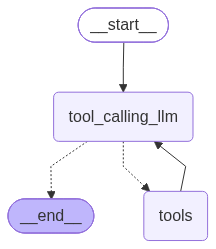

In [23]:
### State Graph 

from langgraph.graph import StateGraph , START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

### Adding Edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ## If the latest message (result) fro massistant is a tool call -> tools_condition routes to tools
    ## If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## complie the graph


graph = builder.compile()

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [24]:
response = graph.invoke({"messages":"what is recent political news of India and then add 5 and 15"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is recent political news of India and then add 5 and 15
================================== Ai Message ==================================

**Recent Political News in India (as of early October 2024)**  

| Date | Event | Key Points |
|------|-------|------------|
| **Oct 2 2024** | **Prime Minister Narendra Modi announces a “National Digital Health Mission” expansion** | • New budget allocation of ₹12,000 cr for digital health infrastructure.<br>• Focus on AI‑driven diagnostics and tele‑medicine in rural districts. |
| **Oct 1 2024** | **Cabinet reshuffle – 7 new ministers appointed** | • Includes a new Minister for Climate Change and a Minister for Digital Infrastructure.<br>• Modi cites “fresh energy” for the 2024‑25 fiscal year. |
| **Sep 28 2024** | **Opposition leaders call for a “vote of confidence” on the current government’s economic reforms** | • The Indian National Congress and the Aam Aadmi

Adding Memory In Agentic Graph

In [25]:
response = graph.invoke({"messages":"Hello my nme is atul"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my nme is atul
================================== Ai Message ==================================

Hello Atul! 👋 How can I help you today?


In [26]:
response = graph.invoke({"messages":"what is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is my name
================================== Ai Message ==================================

I don’t have that information. Could you let me know what your name is?


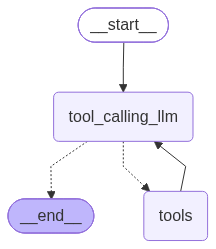

In [27]:
### State Graph 

from langgraph.graph import StateGraph , START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver # it is in memory checkpoint saver stores checkpoint in memory using a default dict

memory = MemorySaver() # this memeory checkpint is added while we compplie the graph

### Node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}


## Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

### Adding Edges

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    ## If the latest message (result) fro massistant is a tool call -> tools_condition routes to tools
    ## If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## complie the graph

## 
graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
## creating a thread

config = {"configurable":{"thread_id":"1"}}

response = graph.invoke({"messages":"Hi my name is Atul"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Atul', additional_kwargs={}, response_metadata={}, id='231915b6-b487-4e59-b27a-898bc6e5e4f9'),
  AIMessage(content='Hello Atul! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'User: "Hi my name is Atul". We should greet, ask how we can help. No function call.'}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 143, 'total_tokens': 190, 'completion_time': 0.048824836, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.007024575, 'prompt_tokens_details': None, 'queue_time': 0.331345659, 'total_time': 0.055849411}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_851252edc2', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a1067a-5d63-7011-bd08-9829d728efd9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 143, 'output_tokens': 47, 'total_tokens': 190, 'output_token_de

In [29]:
response['messages'][-1].content

'Hello Atul! 👋 How can I help you today?'

In [30]:
response = graph.invoke({"messages":"what is my name"},config=config)
print(response['messages'][-1].content)

Your name is Atul.


In [31]:
response = graph.invoke({"messages":"Hey do you remember my name"},config=config)
print(response['messages'][-1].content)

Yes, your name is Atul.


Streaming

In [32]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [33]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

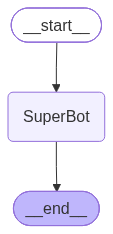

In [34]:
graph = StateGraph(State)

## node 

graph.add_node("SuperBot",superbot)

## Edges
graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)

graph_builder = graph.compile(checkpointer=memory)

## Display

from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [35]:
## Invocation

config = {"configurable":{"thread_id":"1"}}

graph_builder.invoke({'messages':"Hi, My name is Atul and i like cricket"},config)

{'messages': [HumanMessage(content='Hi, My name is Atul and i like cricket', additional_kwargs={}, response_metadata={}, id='64c1db7b-c240-48b1-bee0-5a54a111673d'),
  AIMessage(content='Hello Atul! 👋 Great to meet a cricket fan. Which team or player do you follow the most? And do you play cricket yourself, or just watch it?', additional_kwargs={'reasoning_content': 'User says: "Hi, My name is Atul and i like cricket". They greet. We should respond friendly. Also we can ask about cricket. No policy conflict.'}, response_metadata={'token_usage': {'completion_tokens': 80, 'prompt_tokens': 82, 'total_tokens': 162, 'completion_time': 0.08326472, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.004343205, 'prompt_tokens_details': None, 'queue_time': 0.30647795, 'total_time': 0.087607925}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_4a35f7bd1b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_ru

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.